# LSTM Window Embeddings

**Предполагается**, что данные уже подготовлены:
- нормализованы
- нарезаны на окна
- все признаки вычислены

На вход подаём массивы `(N, T, F)`.  
На выходе получаем эмбеддинги `(N, hidden_size)` — скрытые состояния LSTM,
обученные предсказывать лог-доходность следующего бара.

In [17]:
from prep import *
from LSTM_embedder import LSTMEmbedder

In [18]:
import sys
from pathlib import Path

import numpy as np
import torch

# Ноутбук лежит рядом с LSTM_embedder.py — ищем файл от cwd вниз
_cwd = Path.cwd()
PREP_DIR = next(
    p for p in [
        _cwd,
        _cwd / "src" / "data" / "data_analisys&prep",
    ]
    if (p / "LSTM_embedder.py").exists()
)
if str(PREP_DIR) not in sys.path:
    sys.path.insert(0, str(PREP_DIR))



## 1. Данные

Подставьте сюда свои массивы.  
Ниже — заглушка с синтетическими данными для проверки кода.

In [19]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

from tickers import TICKERS

In [20]:
%load_ext autoreload
%autoreload 2
from prep import *


dataset = cut_on_windows(
    tickers=TICKERS,          
    interval="hourly",        
    seq_len=30,               
    step_size=15,              
    path="../moex_candles",     
    horizon=1,                 
    feature_cols=None,          
    add_indicators=True,      
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
X_train, y_train, X_val, y_val, X_test, y_test = get_train_val_test_data(dataset)
nfeat = X_train.shape[2]

## 2. Обучение

In [22]:
HIDDEN_SIZE = 64
NUM_LAYERS  = 3
DROPOUT     = 0.1
EPOCHS      = 100
BATCH_SIZE  = 512
LR          = 1e-3

model = LSTMEmbedder(
    input_size  = nfeat,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT,
)
print(f"Device     : {next(model.parameters()).device}")
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR / 20)

model.fit(
    X_train, y_train,
    X_val, y_val,
    optimizer  = optimizer,
    scheduler  = scheduler,
    epochs     = EPOCHS,
    batch_size = BATCH_SIZE,
)

Device     : cuda:0
Parameters : 88,129
Epoch  10/100  train=0.000439  val=0.000187  lr=9.77e-04
Epoch  20/100  train=0.000420  val=0.000188  lr=9.09e-04
Epoch  30/100  train=0.000401  val=0.000192  lr=8.04e-04
Epoch  40/100  train=0.000380  val=0.000187  lr=6.72e-04
Epoch  50/100  train=0.000300  val=0.000264  lr=5.25e-04
Epoch  60/100  train=0.000260  val=0.000182  lr=3.78e-04
Epoch  70/100  train=0.000248  val=0.000189  lr=2.46e-04
Epoch  80/100  train=0.000240  val=0.000190  lr=1.41e-04
Epoch  90/100  train=0.000236  val=0.000189  lr=7.32e-05
Epoch 100/100  train=0.000232  val=0.000190  lr=5.00e-05


LSTMEmbedder(
  (lstm): LSTM(18, 64, num_layers=3, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

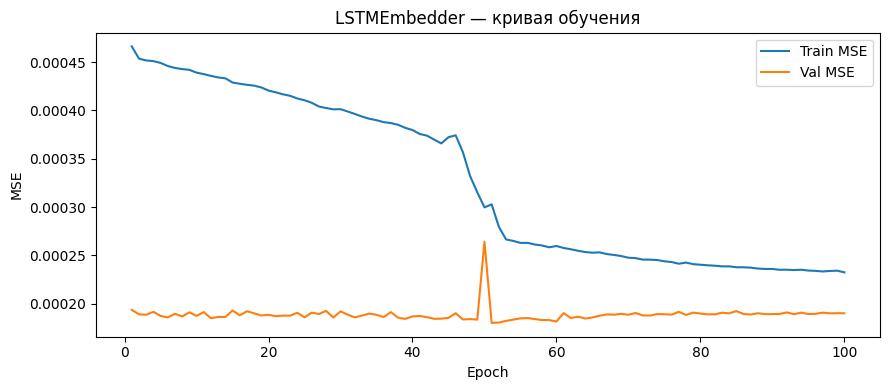

In [23]:
model.plot_loss()

## 3. Извлечение эмбеддингов

In [24]:
emb_train = model.transform(X_train)  # (N_train, hidden_size)
emb_val   = model.transform(X_val)    # (N_val,   hidden_size)

print(f"emb_train : {emb_train.shape}")
print(f"emb_val   : {emb_val.shape}")

emb_train : (214696, 64)
emb_val   : (79626, 64)


## 4. Сохранение

In [25]:
import numpy as np

# Сохраняем в src/data/embeddings/ (на уровень выше от текущей папки)
EMB_DIR = PREP_DIR.parent / "embeddings"
EMB_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = EMB_DIR / f"lstm_embedder_h{HIDDEN_SIZE}_l{NUM_LAYERS}.pt"
model.save(str(MODEL_PATH))
print(f"Модель  : {MODEL_PATH}")

EMB_TRAIN_PATH = EMB_DIR / "emb_train.npy"
EMB_VAL_PATH   = EMB_DIR / "emb_val.npy"
np.save(str(EMB_TRAIN_PATH), emb_train)
np.save(str(EMB_VAL_PATH),   emb_val)
print(f"Эмбеддинги train : {EMB_TRAIN_PATH}")
print(f"Эмбеддинги val   : {EMB_VAL_PATH}")

Модель  : /home/dzyoma/hw/dl/CourseBDAMI3/src/data/embeddings/lstm_embedder_h64_l3.pt
Эмбеддинги train : /home/dzyoma/hw/dl/CourseBDAMI3/src/data/embeddings/emb_train.npy
Эмбеддинги val   : /home/dzyoma/hw/dl/CourseBDAMI3/src/data/embeddings/emb_val.npy


## 5. t-SNE (опционально)

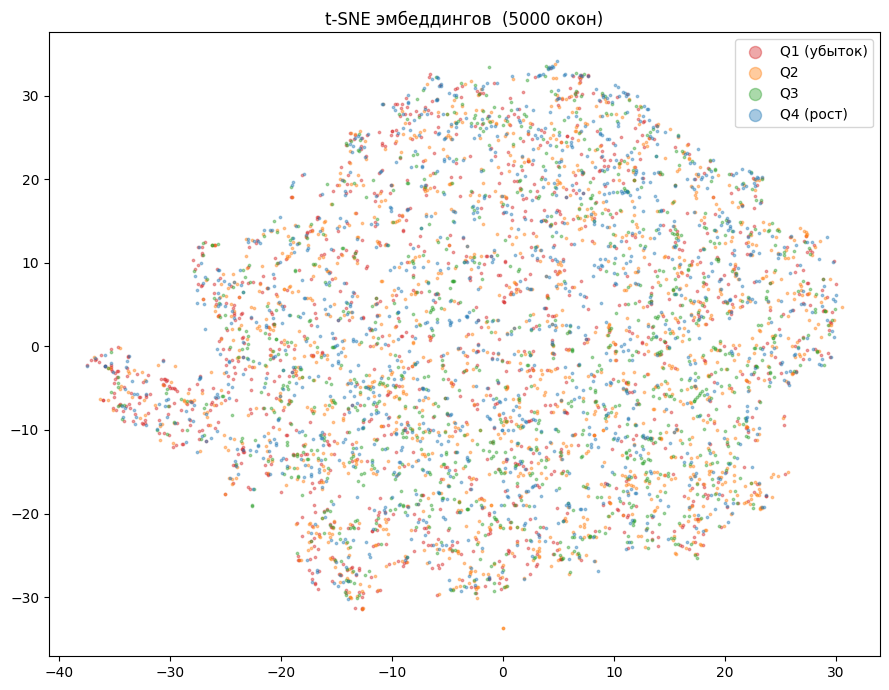

In [26]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

N_VIZ = 5_000
idx   = np.random.choice(len(emb_val), size=min(N_VIZ, len(emb_val)), replace=False)

coords = TSNE(n_components=2, perplexity=40, max_iter=500, random_state=42).fit_transform(
    emb_val[idx]
)

# Раскраска по квартилю доходности
import pandas as pd
q = pd.qcut(y_val[idx], q=4, labels=["Q1 (убыток)", "Q2", "Q3", "Q4 (рост)"])
colors = {"Q1 (убыток)": "#d62728", "Q2": "#ff7f0e", "Q3": "#2ca02c", "Q4 (рост)": "#1f77b4"}

fig, ax = plt.subplots(figsize=(9, 7))
for label, color in colors.items():
    mask = q == label
    ax.scatter(coords[mask, 0], coords[mask, 1], s=3, alpha=0.4, color=color, label=label, rasterized=True)
ax.set_title(f"t-SNE эмбеддингов  ({len(idx)} окон)")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 6. K-Means кластеризация эмбеддингов

Кластеры соответствуют **рыночным режимам** (паттернам поведения цены),  
закодированным LSTM.  

Шаги:
1. Elbow + Silhouette — выбираем оптимальное K  
2. Обучаем KMeans на train-эмбеддингах  
3. Назначаем кластеры val-эмбеддингам  
4. Профилируем кластеры по доходности  
5. Визуализируем на t-SNE плоскости

K= 3  inertia=4360.7  silhouette=0.7141
K= 4  inertia=3852.6  silhouette=0.7361
K= 5  inertia=3462.3  silhouette=0.5943
K= 6  inertia=3177.4  silhouette=0.5792
K= 7  inertia=3008.0  silhouette=0.5074
K= 8  inertia=2862.7  silhouette=0.4515
K= 9  inertia=2746.8  silhouette=0.2394
K=10  inertia=2659.0  silhouette=0.2980
K=11  inertia=2574.7  silhouette=0.2659
K=12  inertia=2508.1  silhouette=0.2522
K=13  inertia=2454.9  silhouette=0.2434
K=14  inertia=2400.3  silhouette=0.2445
K=15  inertia=2351.5  silhouette=0.2158
K=16  inertia=2310.8  silhouette=0.2300
K=17  inertia=2269.9  silhouette=0.1988
K=18  inertia=2234.4  silhouette=0.2059
K=19  inertia=2202.3  silhouette=0.2033
K=20  inertia=2170.5  silhouette=0.1919


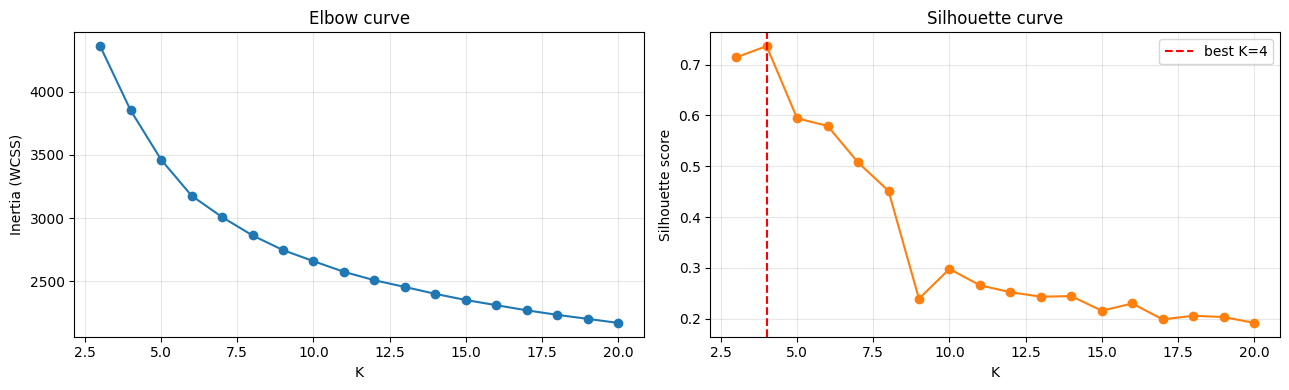


Рекомендуемое K по Silhouette: 4


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# L2-нормализация — косинусное пространство, KMeans работает лучше
emb_train_n = normalize(emb_train)
emb_val_n   = normalize(emb_val)

K_RANGE = range(3, 21)

inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=5, random_state=42)
    labels = km.fit_predict(emb_train_n)
    inertias.append(km.inertia_)
    # silhouette дорогой — считаем на подвыборке
    sample = np.random.choice(len(labels), size=min(10_000, len(labels)), replace=False)
    silhouettes.append(silhouette_score(emb_train_n[sample], labels[sample]))
    print(f"K={k:>2}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_RANGE), inertias, marker="o")
ax1.set_xlabel("K")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow curve")
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, marker="o", color="tab:orange")
ax2.set_xlabel("K")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette curve")
ax2.grid(True, alpha=0.3)

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
ax2.axvline(best_k, color="red", ls="--", label=f"best K={best_k}")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"\nРекомендуемое K по Silhouette: {best_k}")

In [28]:
# ── Финальный KMeans с выбранным K ───────────────────────────────────────────
K = best_k   # можно переопределить вручную: K = 8

kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=42)
kmeans.fit(emb_train_n)

train_labels = kmeans.labels_                    # (N_train,)
val_labels   = kmeans.predict(emb_val_n)         # (N_val,)

print(f"K = {K}")
print(f"Train cluster distribution:")
unique, counts = np.unique(train_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  cluster {c:>2}: {n:>7}  ({100*n/len(train_labels):.1f}%)")

K = 4
Train cluster distribution:
  cluster  0:  198222  (92.3%)
  cluster  1:   12946  (6.0%)
  cluster  2:    2277  (1.1%)
  cluster  3:    1251  (0.6%)


### Профиль кластеров по доходности

Для каждого кластера смотрим: средняя доходность, волатильность, размер.

In [29]:
import pandas as pd

def cluster_profile(labels: np.ndarray, y: np.ndarray, split: str) -> pd.DataFrame:
    df = pd.DataFrame({"cluster": labels, "ret": y})
    profile = (
        df.groupby("cluster")["ret"]
        .agg(
            count="count",
            mean_ret="mean",
            std_ret="std",
            sharpe=lambda x: x.mean() / (x.std() + 1e-9),
            pos_rate=lambda x: (x > 0).mean(),
        )
        .reset_index()
    )
    profile["share_%"] = 100 * profile["count"] / profile["count"].sum()
    profile = profile.sort_values("mean_ret", ascending=False).reset_index(drop=True)
    print(f"\n── {split} cluster profile ──")
    print(profile.to_string(index=False, float_format="{:.5f}".format))
    return profile

train_profile = cluster_profile(train_labels, y_train, "TRAIN")
val_profile   = cluster_profile(val_labels,   y_val,   "VAL")


── TRAIN cluster profile ──
 cluster  count  mean_ret  std_ret   sharpe  pos_rate  share_%
       3   1251   0.06210  0.07756  0.80072   0.80416  0.58268
       1  12946   0.00236  0.02636  0.08972   0.44871  6.02992
       0 198222   0.00001  0.01413  0.00097   0.44271 92.32682
       2   2277  -0.04878  0.12060 -0.40452   0.13395  1.06057

── VAL cluster profile ──
 cluster  count  mean_ret  std_ret   sharpe  pos_rate  share_%
       3     69   0.00426  0.02411  0.17668   0.52174  0.08666
       1   1007   0.00110  0.01606  0.06846   0.47766  1.26466
       0  78342   0.00008  0.01342  0.00628   0.47092 98.38746
       2    208  -0.00795  0.04233 -0.18782   0.32692  0.26122


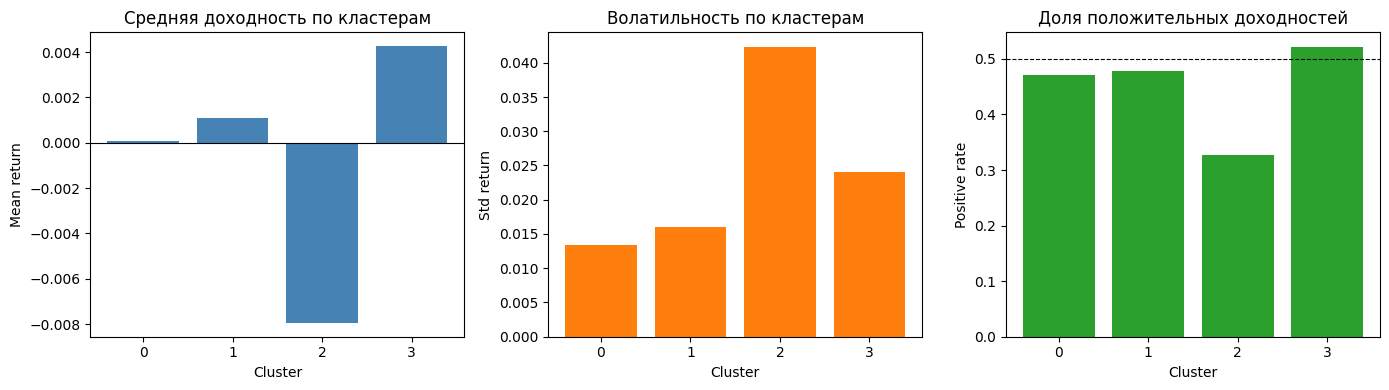

In [30]:
# Визуализация профиля: mean_ret и std_ret по кластерам (val)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vp = val_profile.sort_values("cluster")

axes[0].bar(vp["cluster"].astype(str), vp["mean_ret"], color="steelblue")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Средняя доходность по кластерам")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Mean return")

axes[1].bar(vp["cluster"].astype(str), vp["std_ret"], color="tab:orange")
axes[1].set_title("Волатильность по кластерам")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Std return")

axes[2].bar(vp["cluster"].astype(str), vp["pos_rate"], color="tab:green")
axes[2].axhline(0.5, color="black", lw=0.8, ls="--")
axes[2].set_title("Доля положительных доходностей")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Positive rate")

plt.tight_layout()
plt.show()

### t-SNE раскрашенный по кластерам

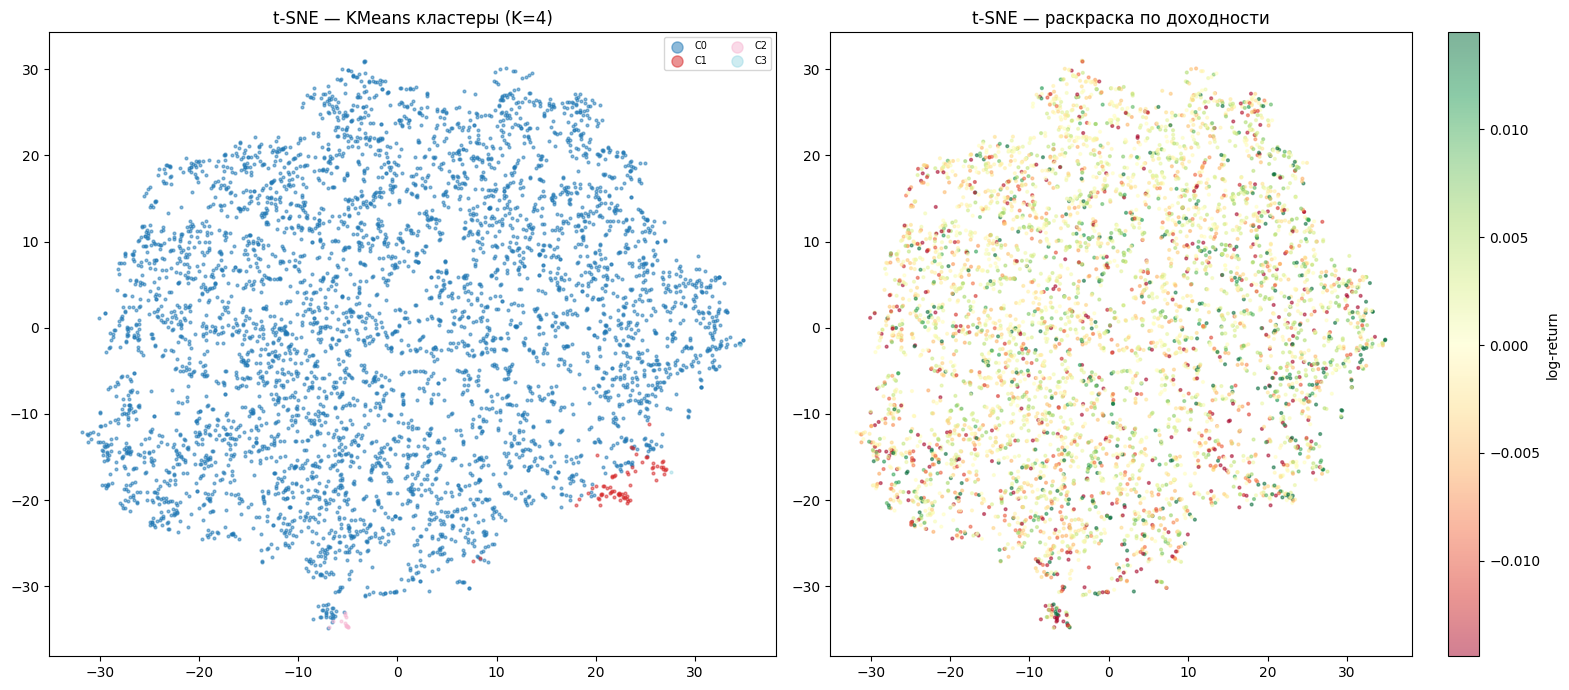

In [31]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

N_VIZ = 5_000
idx   = np.random.choice(len(emb_val_n), size=min(N_VIZ, len(emb_val_n)), replace=False)

# Переиспользуем coords из ячейки t-SNE выше, или пересчитываем
coords_km = TSNE(n_components=2, perplexity=40, max_iter=500, random_state=42).fit_transform(
    emb_val_n[idx]
)

palette = cm.get_cmap("tab20", K)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# — раскраска по кластеру
for c in range(K):
    mask = val_labels[idx] == c
    axes[0].scatter(
        coords_km[mask, 0], coords_km[mask, 1],
        s=4, alpha=0.5, color=palette(c), label=f"C{c}", rasterized=True,
    )
axes[0].set_title(f"t-SNE — KMeans кластеры (K={K})")
axes[0].legend(markerscale=4, fontsize=7, ncol=2)

# — раскраска по доходности
sc = axes[1].scatter(
    coords_km[:, 0], coords_km[:, 1],
    c=y_val[idx], cmap="RdYlGn",
    vmin=np.percentile(y_val[idx], 5),
    vmax=np.percentile(y_val[idx], 95),
    s=4, alpha=0.5, rasterized=True,
)
plt.colorbar(sc, ax=axes[1], label="log-return")
axes[1].set_title("t-SNE — раскраска по доходности")

plt.tight_layout()
plt.show()

### Сохранение результатов кластеризации

In [32]:
import joblib

EMB_DIR = MODEL_PATH.parent

# Веса KMeans
KMEANS_PATH = EMB_DIR / f"kmeans_k{K}.pkl"
joblib.dump(kmeans, KMEANS_PATH)
print(f"KMeans   : {KMEANS_PATH}")

# Метки кластеров
np.save(str(EMB_DIR / "train_labels.npy"), train_labels)
np.save(str(EMB_DIR / "val_labels.npy"),   val_labels)
print(f"Labels   : train_labels.npy, val_labels.npy")

# Профиль кластеров
PROFILE_PATH = EMB_DIR / f"cluster_profile_k{K}.csv"
val_profile.to_csv(PROFILE_PATH, index=False)
print(f"Profile  : {PROFILE_PATH}")

KMeans   : /home/dzyoma/hw/dl/CourseBDAMI3/src/data/embeddings/kmeans_k4.pkl
Labels   : train_labels.npy, val_labels.npy
Profile  : /home/dzyoma/hw/dl/CourseBDAMI3/src/data/embeddings/cluster_profile_k4.csv
